In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [163]:
# Create the folder if it does not exist
output_folder = "../visualization"
os.makedirs(output_folder, exist_ok=True)

In [164]:
df = pd.read_csv("../data/clean/Zomato_cleaned.csv")
print("Load Data Successfully...!")

Load Data Successfully...!


In [165]:
df.shape

(780, 7)

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             780 non-null    str    
 1   online_order     780 non-null    str    
 2   book_table       780 non-null    str    
 3   rate             780 non-null    float64
 4   votes            780 non-null    int64  
 5   approx_cost      780 non-null    int64  
 6   restaurant_type  780 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 42.8 KB


In [167]:
df.isnull().sum()

name               0
online_order       0
book_table         0
rate               0
votes              0
approx_cost        0
restaurant_type    0
dtype: int64

In [168]:
df.describe()

,rate,votes,approx_cost
count,780.000000,780.000000,780.000000
mean,3.694103,325.348718,457.974359
std,0.402261,698.933899,226.909808
min,2.600000,0.000000,90.000000
25%,3.400000,22.000000,270.000000
50%,3.800000,76.500000,440.000000
75%,4.000000,306.000000,635.000000
max,4.600000,5357.000000,1040.000000


In [169]:
df.duplicated().sum()

np.int64(0)

In [170]:
df["restaurant_type"].value_counts()

restaurant_type
Dining    546
Cafes     129
Other      54
Buffet     51
Name: count, dtype: int64

#### Restaurant Type Analysis

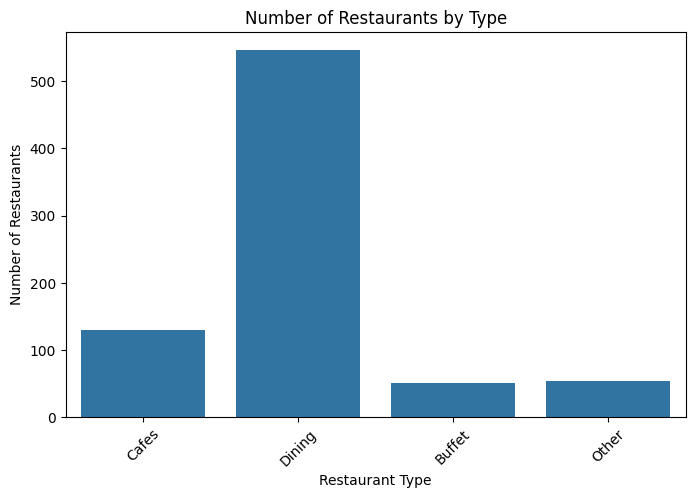

In [171]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="restaurant_type")
plt.title("Number of Restaurants by Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)

plt.savefig(
    os.path.join(output_folder, "restaurant_type_count.png"),
    bbox_inches="tight",
)

plt.show()

#### What is the average restaurant rating

In [172]:

average_rating = df["rate"].mean()
print("Average Restaurant Rating:", round(average_rating, 2))

Average Restaurant Rating: 3.69


#### What is the distribution of restaurant ratings?

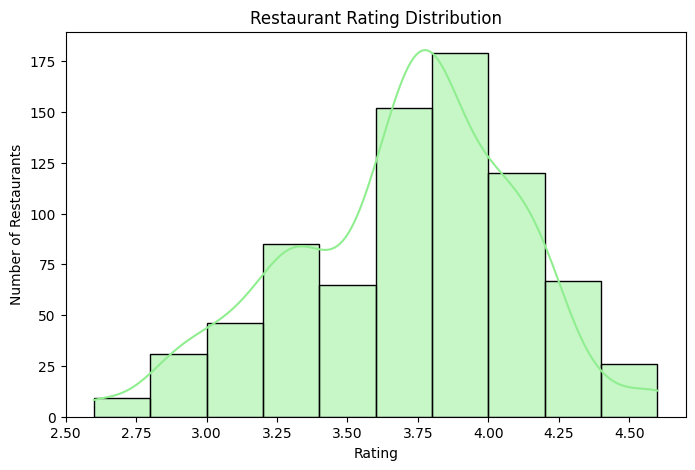

In [173]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="rate",
    bins=10,
    kde=True,
    color='lightgreen'
)

plt.title("Restaurant Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.savefig(
    os.path.join(output_folder, "restaurant_Distribution.png"),
    bbox_inches="tight",
)

plt.show()

#### Which restaurant type has the highest average rating?

In [174]:
type_rating = (
    df.groupby("restaurant_type")["rate"]
    .mean()
    .sort_values(ascending=False)
)

print(type_rating)

restaurant_type
Other     4.020370
Buffet    3.874510
Cafes     3.814729
Dining    3.616484
Name: rate, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15200\3183099670.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


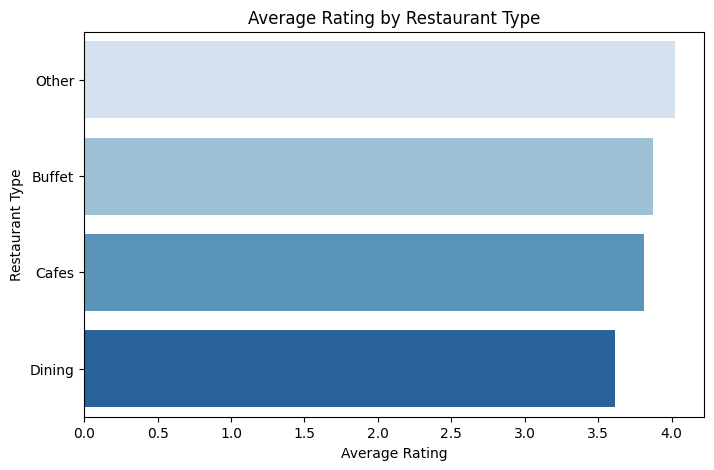

In [175]:

plt.figure(figsize=(8,5))

sns.barplot(
    x=type_rating.values,
    y=type_rating.index,
    palette='Blues'    
)

plt.title("Average Rating by Restaurant Type")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Type")

plt.savefig(
    os.path.join(output_folder, "average_rating.png"),
    bbox_inches="tight",
)

plt.show()

#### How many restaurants offer online ordering?

In [176]:
df["online_order"].value_counts()

online_order
No     419
Yes    361
Name: count, dtype: int64

C:\Users\Dell\AppData\Local\Temp\ipykernel_15200\849993219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


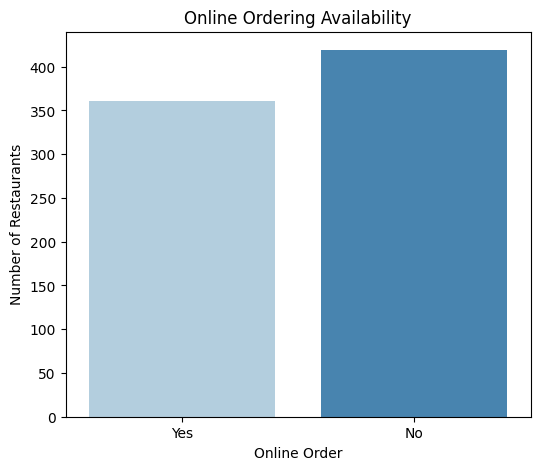

In [177]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="online_order",
    palette='Blues'
)

plt.title("Online Ordering Availability")
plt.xlabel("Online Order")
plt.ylabel("Number of Restaurants")

plt.savefig(
    os.path.join(output_folder, "Online_ordering_Distribution.png"),
    bbox_inches="tight",
)
plt.show()

In [178]:
# calculate Percentage
online_percentage = (
    df["online_order"].value_counts(normalize=True) * 100
)

print(online_percentage.round(2))

online_order
No     53.72
Yes    46.28
Name: proportion, dtype: float64


#### Do restaurants offering online ordering have higher ratings?

In [179]:
online_rating = (
    df.groupby("online_order")["rate"]
    .mean()
)

print(online_rating)

online_order
No     3.536516
Yes    3.877008
Name: rate, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15200\2612266909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


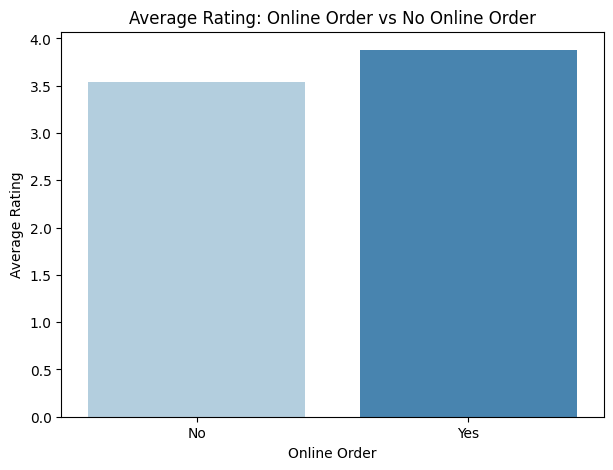

In [180]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=online_rating.index,
    y=online_rating.values,
    palette='Blues',
)

plt.title("Average Rating: Online Order vs No Online Order")
plt.xlabel("Online Order")
plt.ylabel("Average Rating")

plt.savefig(
    os.path.join(output_folder, "Ordering_vs_Rating.png"),
    bbox_inches="tight",
)
plt.show()

#### How many restaurants offer table booking?

In [181]:
df["book_table"].value_counts()

book_table
No     711
Yes     69
Name: count, dtype: int64

C:\Users\Dell\AppData\Local\Temp\ipykernel_15200\732311099.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


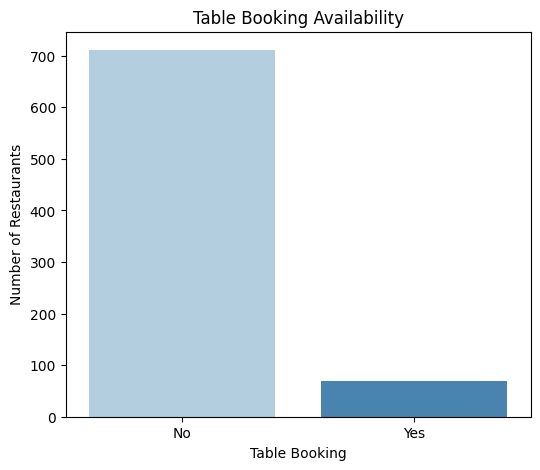

In [182]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="book_table",
    palette='Blues'
)

plt.title("Table Booking Availability")
plt.xlabel("Table Booking")
plt.ylabel("Number of Restaurants")
plt.savefig(
    os.path.join(output_folder, "Table_Booking_Distribution.png"),
    bbox_inches="tight",
)
plt.show()

#### Table Booking vs Rating

In [183]:
booking_rating = (
    df.groupby("book_table")["rate"]
    .mean()
)

print(booking_rating)

book_table
No     3.649086
Yes    4.157971
Name: rate, dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15200\781669278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


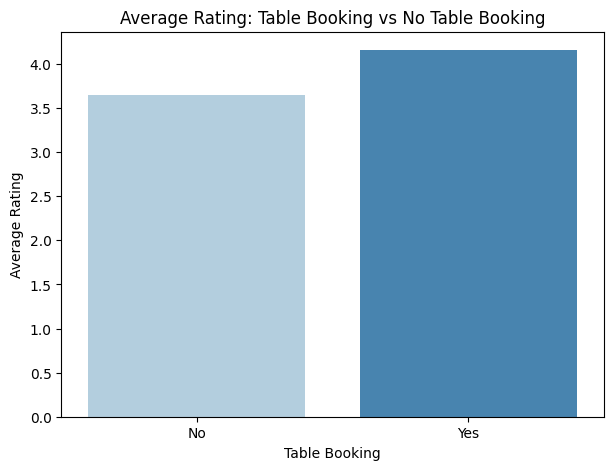

In [184]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=booking_rating.index,
    y=booking_rating.values,
    palette='Blues'
    
)

plt.title("Average Rating: Table Booking vs No Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")
plt.savefig(
    os.path.join(output_folder, "TableBooking_vs_Rating.png"),
    bbox_inches="tight",
)
plt.show()

#### Cost Analysis

#### What is the average cost for two people?

In [185]:
average_cost = df["approx_cost"].mean()

print(
    "Average Cost for Two People:",
    round(average_cost, 2)
)

Average Cost for Two People: 457.97


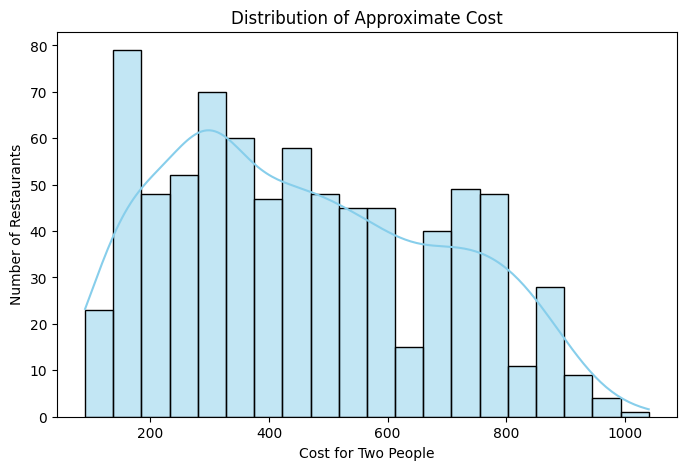

In [186]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="approx_cost",
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title("Distribution of Approximate Cost")
plt.xlabel("Cost for Two People")
plt.ylabel("Number of Restaurants")
plt.savefig(
    os.path.join(output_folder, "Cost_Distribution.png"),
    bbox_inches="tight",
)
plt.show()

#### Does higher restaurant cost correspond to higher ratings?

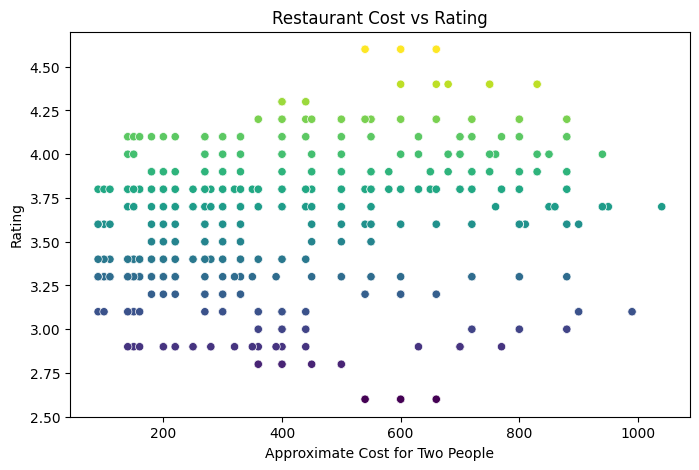

In [187]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="approx_cost",
    y="rate",
    hue="rate", 
    palette="viridis", 
    legend=False,
)

plt.title("Restaurant Cost vs Rating")
plt.xlabel("Approximate Cost for Two People")
plt.ylabel("Rating")
plt.savefig(
    os.path.join(output_folder, "Cost_vs_Rating.png"),
    bbox_inches="tight",
)
plt.show()

In [188]:
correlation = df["approx_cost"].corr(df["rate"])

print("Cost-Rating Correlation:", round(correlation, 2))

Cost-Rating Correlation: 0.25


#### Which restaurants receive the most customer votes?

In [189]:
top_voted = (
    df.sort_values("votes", ascending=False)
      [["name", "rate", "votes", "approx_cost", "restaurant_type"]]
      .head(10)
)

top_voted

,name,rate,votes,approx_cost,restaurant_type
18,Empire Restaurant,4.4,5357,750,Other
425,Empire Restaurant,4.4,5352,830,Other
114,Empire Restaurant,4.4,5097,830,Other
6,Empire Restaurant,4.4,5016,750,Other
488,Empire Restaurant,4.4,4884,750,Other
768,Empire Restaurant,4.4,4670,830,Other
611,Empire Restaurant,4.4,4636,680,Other
298,Empire Restaurant,4.4,4545,830,Other
295,Empire Restaurant,4.4,4502,750,Other
110,Meghana Foods,4.4,4401,600,Dining


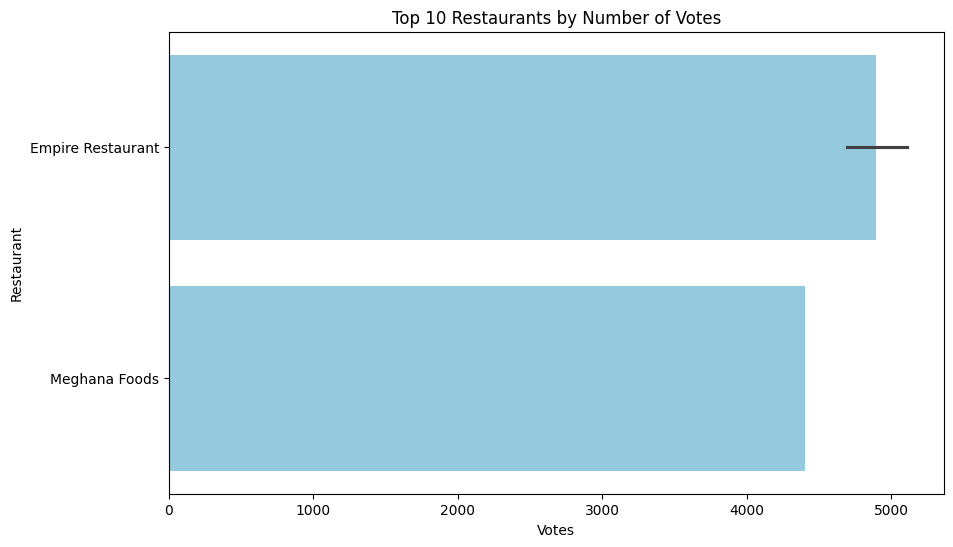

In [190]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_voted, x='votes', y='name', color='skyblue'
)  
plt.title('Top 10 Restaurants by Number of Votes')
plt.xlabel('Votes')
plt.ylabel('Restaurant')
plt.savefig(
    os.path.join(output_folder, 'Restaurants_by_Votes.png'),
    bbox_inches='tight',
)
plt.show()


#### Which restaurants have the highest ratings?

In [191]:
top_rated = (
    df.sort_values(
        ["rate", "votes"],
        ascending=[False, False]
    )
    [["name", "rate", "votes", "approx_cost", "restaurant_type"]]
    .head(10)
)

top_rated

,name,rate,votes,approx_cost,restaurant_type
602,Onesta,4.6,2791,540,Other
703,Onesta,4.6,2764,600,Cafes
482,Onesta,4.6,2744,600,Cafes
707,Onesta,4.6,2627,600,Cafes
714,Onesta,4.6,2624,540,Cafes
73,Onesta,4.6,2566,540,Other
116,Onesta,4.6,2560,660,Cafes
133,Onesta,4.6,2556,600,Other
271,Onesta,4.6,2556,600,Cafes
737,Onesta,4.6,2553,660,Other


### Correlation Analysis

In [192]:
correlation_matrix = df[
    ["rate", "votes", "approx_cost"]
].corr()

print(correlation_matrix)

                 rate     votes  approx_cost
rate         1.000000  0.491544     0.245746
votes        0.491544  1.000000     0.339509
approx_cost  0.245746  0.339509     1.000000


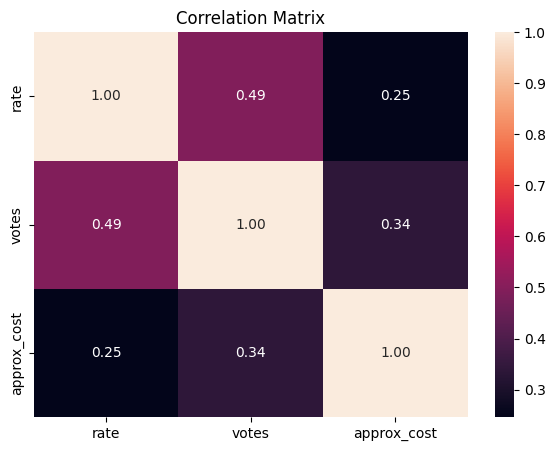

In [193]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.savefig(
    os.path.join(output_folder, "Correlation_Heatmap.png"),
    bbox_inches="tight",
)
plt.show()